<h1><b>Regressão Logística</b><br>
<i>Conjunto de dados Diabetes Health Indicators</i></h1>

<b>Objetivo do modelo:</b><br>
Prever a probabilidade de um paciente ter diabetes sem o uso de variáveis clinicas

### Importação das Bibliotecas

In [11]:
import os
import pandas as pd
import numpy as np
import shap
import sys
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.tree import DecisionTreeClassifier, export_text

Configurações de estilo para os gráficos

In [12]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'utils')))

from plot_config import set_seaborn
set_seaborn()

### Importação e pré-visualização dos dados

In [13]:
df_columns = [
    "age",
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "employment_status",
    "smoking_status",
    "alcohol_consumption_per_week",
    "physical_activity_minutes_per_week",
    "diet_score",
    "sleep_hours_per_day",
    "screen_time_hours_per_day",
    "bmi",
    "diagnosed_diabetes"
]

df = pd.read_csv("./../../data/raw/diabetes_health_indicators.csv",usecols=df_columns)
pd.options.display.float_format = '{:.2f}'.format

display(df.head())
registros = df.shape[0]
print(f"\n{registros} registros e {df.shape[1]} variáveis")

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.70,7.90,7.90,30.50,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.70,6.50,8.70,23.10,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.40,10.00,8.10,22.20,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.40,6.60,5.20,26.80,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.20,7.40,5.00,21.20,1



100000 registros e 14 variáveis


### Treinando uma árvore rasa para encontrar os cortes de idade

In [14]:
tree_discretizer = DecisionTreeClassifier(max_leaf_nodes=4, random_state=42)
tree_discretizer.fit(df[['age']], df["diagnosed_diabetes"])

thresholds = sorted([t for t in tree_discretizer.tree_.threshold if t != -2])
thresholds = [round(t) for t in thresholds]

print(f"Os pontos de corte sugeridos pela árvore são: {thresholds}\n")

tree_rules = export_text(tree_discretizer, feature_names=['age'])
print(tree_rules)

Os pontos de corte sugeridos pela árvore são: [28, 48, 68]

|--- age <= 48.50
|   |--- age <= 28.50
|   |   |--- class: 0
|   |--- age >  28.50
|   |   |--- class: 1
|--- age >  48.50
|   |--- age <= 67.50
|   |   |--- class: 1
|   |--- age >  67.50
|   |   |--- class: 1



In [15]:
bins = [-np.inf] + thresholds + [np.inf]

labels = [f"Faixa_{i}" for i in range(len(bins)-1)]

df["age_binned"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

age_stats = (
    df
    .groupby("age_binned")["diagnosed_diabetes"]
    .agg(["count", "mean"])
    .rename(columns={
        "count": "n",
        "mean": "diabetes_rate"
    })
)

print(age_stats)

                n  diabetes_rate
age_binned                      
Faixa_0      8932           0.47
Faixa_1     37278           0.56
Faixa_2     41310           0.63
Faixa_3     12480           0.72


In [16]:
numeric_features = [
    "age",
    "alcohol_consumption_per_week",
    "physical_activity_minutes_per_week",
    "diet_score",
    "sleep_hours_per_day",
    "screen_time_hours_per_day",
    "bmi"
]

categorical_features = [
    #"age_binned",
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "employment_status",
    "smoking_status"
]

numeric_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("interactions", PolynomialFeatures(
        degree=2,
        interaction_only=True,
        include_bias=False
    ))
])

categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        l1_ratio=1,
        solver="saga",
        max_iter=2000
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    df.drop("diagnosed_diabetes", axis=1),
    df["diagnosed_diabetes"],
    test_size=0.2,
    random_state=42
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [17]:
poly = model.named_steps["preprocessor"]\
           .named_transformers_["num"]\
           .named_steps["interactions"]

poly.get_feature_names_out(numeric_features)

array(['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'age alcohol_consumption_per_week',
       'age physical_activity_minutes_per_week', 'age diet_score',
       'age sleep_hours_per_day', 'age screen_time_hours_per_day',
       'age bmi',
       'alcohol_consumption_per_week physical_activity_minutes_per_week',
       'alcohol_consumption_per_week diet_score',
       'alcohol_consumption_per_week sleep_hours_per_day',
       'alcohol_consumption_per_week screen_time_hours_per_day',
       'alcohol_consumption_per_week bmi',
       'physical_activity_minutes_per_week diet_score',
       'physical_activity_minutes_per_week sleep_hours_per_day',
       'physical_activity_minutes_per_week screen_time_hours_per_day',
       'physical_activity_minutes_per_week bmi',
       'diet_score sleep_hours_per_day',
       'diet_score screen_time_hours_per_day', 'diet_score bm

In [18]:
# 1
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
# 2
coefficients = model.named_steps["classifier"].coef_[0]
# 3
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefficients
})
# 4
selected_features = coef_df[coef_df["coef"] != 0]

selected_features.sort_values("coef", ascending=False)
# 5
removed_features = coef_df[coef_df["coef"] == 0]
# 6
coef_df["abs_coef"] = coef_df["coef"].abs()

coef_df.sort_values("abs_coef", ascending=False)


,feature,coef,abs_coef
0,num__age,0.28,0.28
2,num__physical_activity_minutes_per_week,-0.20,0.20
29,cat__gender_Other,0.16,0.16
6,num__bmi,0.15,0.15
3,num__diet_score,-0.06,0.06
41,cat__employment_status_Retired,-0.04,0.04
5,num__screen_time_hours_per_day,0.04,0.04
36,cat__education_level_Postgraduate,-0.04,0.04
31,cat__ethnicity_Hispanic,-0.03,0.03
32,cat__ethnicity_Other,0.03,0.03


In [19]:
param_dist = [
    {
        "classifier__solver": ["saga"],
        "classifier__l1_ratio": [1],
        "classifier__C": np.logspace(-4, 2, 100)
    },
    {
        "classifier__solver": ["lbfgs"],
        "classifier__l1_ratio": [0],
        "classifier__C": np.logspace(-4, 2, 100)
    }
]


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=30,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("Melhor configuração:")
print(random_search.best_params_)

print("Melhor ROC AUC na validação:")
print(random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhor configuração:
{'classifier__solver': 'saga', 'classifier__l1_ratio': 1, 'classifier__C': np.float64(0.006579332246575682)}
Melhor ROC AUC na validação:
0.6113027421018532


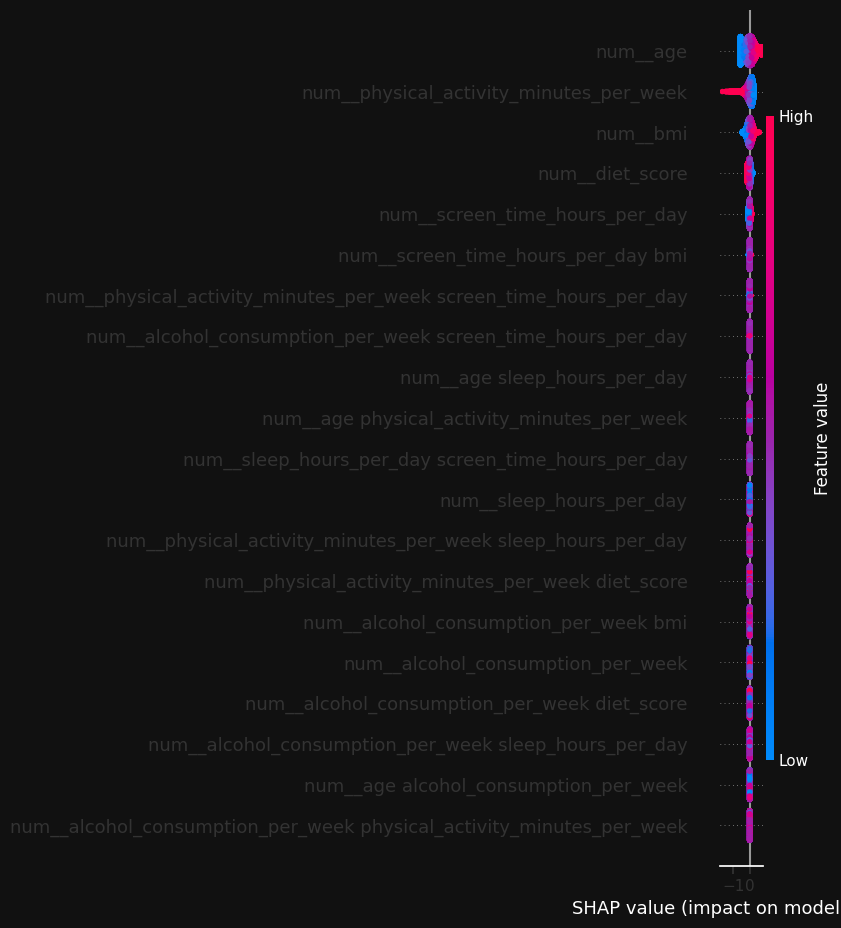

In [20]:
y_pred_prob = best_model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_pred_prob)


X_train_transformed = best_model.named_steps["preprocessor"].transform(X_train)

explainer = shap.LinearExplainer(
    best_model.named_steps["classifier"],
    X_train_transformed
)

shap_values = explainer(X_train_transformed)

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names
)